In [11]:
from typing import TypedDict, Annotated

from dotenv import load_dotenv
from langchain_core.messages import HumanMessage, BaseMessage
from langchain_groq import ChatGroq
from langchain_tavily import TavilySearch
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
from langgraph.types import interrupt, Command

load_dotenv()

True

In [12]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]
    approved: bool

In [13]:
llm = ChatGroq(model="qwen/qwen3-32b", temperature=0.4, reasoning_format="hidden")

search_tool = TavilySearch(
    max_results=1,
    topic="general",
    include_images=False,
    search_depth="basic"
)

tool_list = [search_tool]
llm_with_tool = llm.bind_tools(tool_list)

In [14]:
def chat_node(state: ChatState) -> ChatState:
    # print(list(state["messages"]))
    response_llm = llm_with_tool.invoke(input=state["messages"])
    return {"messages": [response_llm]}

In [15]:
tools_node = ToolNode(tool_list)

In [16]:
def should_continue(state: ChatState) -> str:
    """Determine if we should continue or end the conversation."""
    messages = state["messages"]
    last_message = messages[-1]

    # If no tools were called, we're done
    if not last_message.tool_calls:
        return END
    else:
        return "ask_human"

In [17]:
# Interactive human approval node can only be used in langgraph node and not in the conditional edge logic. This is because the conditional edge logic is not interactive and cannot wait for human input.
def ask_human(state: ChatState) -> ChatState:
    decision = interrupt({
        "type": "tool_decision",
        "tool_call": state["messages"][-1].tool_calls[0],
        "user_message": "LLM is trying to access the tool, do you want to allow it yes or no?",
    })
    return {"approved": decision["allow"] == "yes"}


def after_asking_human(state: ChatState) -> str:
    # Honor the human's decision: run the tool only if approved.
    return "tools" if state.get("approved", False) else END

In [18]:
checkpointer = InMemorySaver()
graph = StateGraph(ChatState)

graph.add_node("chat_node", chat_node)
graph.add_node("tools", tools_node)
graph.add_node("ask_human", ask_human)

graph.add_edge(START, "chat_node")
graph.add_conditional_edges("chat_node", should_continue, {"ask_human": "ask_human", END: END})
graph.add_conditional_edges("ask_human", after_asking_human, {"tools": "tools", END: END})
graph.add_edge("tools", "chat_node")

workflow = graph.compile(checkpointer=checkpointer)

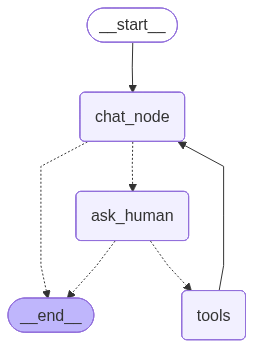

In [19]:
workflow

In [20]:
thread_id = "mychat-ui-4"
config = {"configurable": {"thread_id": thread_id}}

while True:
    user_message = input("Human: ")
    print(f"Human: {user_message}")
    if user_message.lower().strip() in ["bye", "exit", "quit"]:
        break

    response = workflow.invoke(input={"messages": [HumanMessage(content=user_message)]}, config=config)

    while workflow.get_state(config=config).interrupts:
        user_feedback_on_interrupt = input(
            workflow.get_state(config=config).interrupts[-1].value.get("user_message", ""))
        response = workflow.invoke(Command(resume={"allow": user_feedback_on_interrupt.lower().strip()}), config=config)

    response_llm = response["messages"][-1].content
    print(f"AI: {response_llm} \n")



Human: check and tell weather of delhi and mumbai and use 2 tool calls to do so 
AI: Here's the current weather information for Delhi and Mumbai as of July 15, 2026:

**Delhi**  
- **Temperature**: 35°C (Feels like 36°C)  
- **Conditions**: Mist  
- **Humidity**: 53%  
- **Wind**: 12.2 km/h (WNW)  
- **UV Index**: 8.6 (Very High)  
- **Chance of Rain**: 36%  
- **Next Day Forecast**: High of 41°C, Low of 32°C  

**Mumbai**  
- **Temperature**: 32.2°C (Feels like 41.9°C)  
- **Conditions**: Mist  
- **Humidity**: 67%  
- **Wind**: 25.9 km/h (SSW)  
- **UV Index**: 3.0 (Moderate)  
- **Chance of Rain**: 20%  

Both cities show elevated "feels like" temperatures due to humidity and heat. Delhi has a higher risk of rain and a significantly higher UV index compared to Mumbai. 

Human: research on cats and give me summary 
AI: Here’s a summary of key findings about cats based on the research:

---

### **Biology and Behavior**  
1. **Social Structure**: Domestic cats (*Felis catus*) exhibit 

KeyboardInterrupt: Interrupted by user